<a href="https://colab.research.google.com/github/LeandroMurillo/TrabajoFinalPDS/blob/main/TFI_PDS.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

 # Procesamiento y Filtrado de Señales ECG

- Pablo Leonardo Brennan
- Cesar Ezequiel Herrera
- Leandro Murillo
- Ernesto Fidel Orellana

 Este script carga señales de ECG, diseña filtros digitales (pasabajos y supresor de banda) para eliminar ruido y, finalmente, implementa una cadena de filtrado en cascada de manera eficiente. Se comparan dos métodos de diseño de filtros: Transformación Bilineal e Invarianza al Impulso.

 ## 1. Configuración e Inicialización
 Se clona el repositorio de GitHub para acceder a los archivos de señal y se importan las librerías necesarias.

In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import (
    buttord,
    butter,
    bilinear,
    cont2discrete,
    freqz,
    find_peaks,
    tf2sos,
    sosfilt,
)
from scipy.fft import fft, fftfreq, rfft, rfftfreq


def setup_repository(
    repo_url="https://github.com/LeandroMurillo/TrabajoFinalPDS", base_dir="/content"
):
    """
    Clona un repositorio de GitHub si no está ya presente en el directorio.
    """
    repo_name = os.path.basename(repo_url)
    repo_dir = os.path.join(base_dir, repo_name)

    if os.path.exists(repo_dir):
        print(f"El repositorio ya existe en: {repo_dir}")
        return repo_dir

    print("Clonando el repositorio...")
    os.chdir(base_dir)
    os.system(f"git clone {repo_url}")
    print("Repositorio clonado con éxito.")
    return repo_dir

 ## 2. Carga y Visualización de Datos
 Se cargan las señales ECG y se definen funciones de utilidad para graficarlas en el dominio del tiempo y la frecuencia.

In [ ]:
def load_ecg_signals(file_path: str, fs_hz: int) -> tuple[list[np.ndarray], int]:
    """
    Carga las señales ECG desde un archivo .mat.

    Args:
        file_path (str): Ruta al archivo .mat.
        fs_hz (int): Frecuencia de muestreo en Hz.

    Returns:
        tuple: Una tupla conteniendo la lista de señales y la frecuencia de muestreo.
    """
    try:
        mat_data = loadmat(file_path)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo en {file_path}")
        # Intenta buscar en el directorio local como alternativa
        local_path = os.path.basename(file_path)
        try:
            mat_data = loadmat(local_path)
        except FileNotFoundError:
            raise FileNotFoundError(
                f"No se pudo cargar el archivo desde {file_path} ni {local_path}"
            )

    signals = [mat_data[key].squeeze() for key in mat_data if "ecg_signal" in key]
    print(
        f"Se cargaron {len(signals)} señales con una frecuencia de muestreo de {fs_hz} Hz."
    )
    return signals, fs_hz


def plot_signal_spectrum(
    signal: np.ndarray, fs: int, title: str = "Espectro de Frecuencia"
) -> None:
    """
    Grafica la Transformada Rápida de Fourier (FFT) de una señal.
    """
    n = len(signal)
    yf = rfft(signal)
    xf = rfftfreq(n, 1 / fs)
    with plt.style.context("seaborn-v0_8"):
        plt.figure(figsize=(16, 7))
        plt.plot(xf, 20 * np.log10(np.abs(yf) + 1e-9)) # Se suma un epsilon para evitar log(0)
        plt.title(title)
        plt.xlabel("Frecuencia (Hz)")
        plt.ylabel("Magnitud [dB]")
        plt.grid(True, which="both", linestyle="--")
        plt.xlim(0, fs / 2)
        plt.show()


def plot_cardiac_cycle(
    signal: np.ndarray, fs: int, title: str = "Ciclo Cardíaco (PQRST)"
) -> None:
    """
    Detecta el pico R más prominente y grafica una ventana de tiempo a su alrededor.
    """
    # Detección de picos R mejorada
    height_min = np.mean(signal) + 1.5 * np.std(signal)
    distance_min = int(0.3 * fs) # Asume un ritmo cardíaco máximo de 200 bpm
    peaks, _ = find_peaks(signal, height=height_min, distance=distance_min)
    center_peak = peaks[len(peaks) // 2] if peaks.any() else len(signal) // 2

    if not peaks.any():
        print(f"Advertencia: No se detectaron picos R en la señal '{title}'. Usando el centro de la señal.")
        center_peak = len(signal) // 2
    else:
        center_peak = peaks[len(peaks) // 2] # Elige un pico central para una mejor visualización

    # Define una ventana de 600ms alrededor del pico
    pre_samples = int(0.2 * fs)  # 200 ms antes
    post_samples = int(0.4 * fs) # 400 ms antes
    start = max(0, center_peak - pre_samples)
    end = min(len(signal), center_peak + post_samples)
    time_axis = np.arange(start, end) / fs
    with plt.style.context("seaborn-v0_8"):
        plt.figure(figsize=(16, 7))
        plt.plot(time_axis, signal[start:end])
        plt.title(title)
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Amplitud [V]")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

 ## 3. Diseño y Análisis de Filtros
 Se diseñan dos filtros pasabajos y un filtro supresor de banda (notch) para limpiar las señales.

In [ ]:
def design_lowpass_filters(fp, f_stop, gpass, gstop, fs):
    """
    Diseña un filtro pasabajos de Butterworth y lo convierte a digital
    usando la Transformación Bilineal y la Invarianza al Impulso.
    """
    # 1. Diseño del prototipo analógico
    order, wn_analog = buttord(
        2 * np.pi * fp, 2 * np.pi * f_stop, gpass, gstop, analog=True
    )
    b_analog, a_analog = butter(order, wn_analog, btype="low", analog=True)
    print(
        f"Filtro Pasabajos Analógico - Orden: {order}, Frecuencia de corte: {wn_analog/(2*np.pi):.2f} Hz"
    )

    # 2. Transformación a digital
    bz_bilin, az_bilin = bilinear(b_analog, a_analog, fs)
    bz_invar, az_invar, _ = cont2discrete(
        (b_analog, a_analog), 1 / fs, method="impulse"
    )

    return (bz_bilin, az_bilin), (bz_invar.flatten(), az_invar)


def design_notch_filter(f_notch, bandwidth, gpass, gstop, fs):
    """
    Diseña un filtro supresor de banda (notch) usando la Transformación Bilineal con pre-warping.
    """
    # Frecuencias de la banda de rechazo y de paso
    ws = [
        2 * fs * np.tan(np.pi * (f_notch - bandwidth / 2) / fs),
        2 * fs * np.tan(np.pi * (f_notch + bandwidth / 2) / fs),
    ]
    wp = [
        2 * fs * np.tan(np.pi * (f_notch - bandwidth) / fs),
        2 * fs * np.tan(np.pi * (f_notch + bandwidth) / fs),
    ]

    order, wn_analog = buttord(wp, ws, gpass, gstop, analog=True)
    b_analog, a_analog = butter(order, wn_analog, btype="bandstop", analog=True)
    print(f"Filtro Notch Analógico - Orden: {order}")

    bz_notch, az_notch = bilinear(b_analog, a_analog, fs)
    return bz_notch, az_notch


def plot_filter_responses(
    filters: list[tuple[np.ndarray, np.ndarray]], fs: int, titles: list[str]
) -> None:
    """
    Grafica la respuesta en magnitud y fase de una lista de filtros digitales.
    """
    with plt.style.context("seaborn-v0_8"):
        plt.figure(figsize=(16, 7))
        # Gráfico de Magnitud
        ax1 = plt.subplot(1, 2, 1)
        for (bz, az), title in zip(filters, titles):
            w, h = freqz(bz, az, worN=8000)
            ax1.plot((fs * 0.5 / np.pi) * w, 20 * np.log10(np.abs(h)), label=title)
        ax1.set_title("Respuesta en Magnitud")
        ax1.set_xlabel("Frecuencia [Hz]")
        ax1.set_ylabel("Magnitud [dB]")
        ax1.set_ylim(-60, 5)
        ax1.grid(True)
        ax1.legend()

        # Gráfico de Fase
        ax2 = plt.subplot(1, 2, 2)
        for (bz, az), title in zip(filters, titles):
            w, h = freqz(bz, az, worN=8000)
            angles = np.unwrap(np.angle(h))
            ax2.plot((fs * 0.5 / np.pi) * w, angles, label=title)
        ax2.set_title("Respuesta en Fase")
        ax2.set_xlabel("Frecuencia [Hz]")
        ax2.set_ylabel("Fase [rad]")
        ax2.grid(True)
        ax2.legend()
        plt.tight_layout()
        plt.show()

 ## 4. Implementación en Cascada y Procesamiento Final
 Los filtros se combinan en cascada y se aplican a las señales. Se utiliza `scipy.signal.sosfilt` para un procesamiento eficiente.

In [ ]:
def process_signals_in_cascade(signals, filters_sos):
    """
    Filtra las señales usando una cascada de filtros en formato SOS (Second-Order Sections).

    Args:
        signals (list): Lista de señales a procesar.
        filters_sos (list): Lista de filtros en formato SOS.

    Returns:
        tuple: (señales_filtradas, tiempo_promedio_por_muestra_us)
    """
    full_cascade_sos = np.vstack(filters_sos)
    processed_signals = []

    start_time = time.perf_counter()

    for signal in signals:
        # Aplicar el filtro en cascada de una sola vez
        processed_signals.append(sosfilt(full_cascade_sos, signal))

    end_time = time.perf_counter()

    total_time = end_time - start_time
    total_samples = sum(len(s) for s in signals)
    time_per_sample_us = (total_time / total_samples) * 1e6

    print(f"Tiempo total de procesamiento: {total_time:.4f} s")
    print(f"Tiempo promedio por muestra: {time_per_sample_us:.4f} µs")

    return processed_signals, time_per_sample_us


def compare_filtered_signals(
    original: np.ndarray,
    filtered_dict: dict[str, np.ndarray],
    fs: int,
    signal_index: int,
) -> None:
    """
    Compara una señal original con múltiples versiones filtradas en el tiempo y la frecuencia.
    """
    with plt.style.context("seaborn-v0_8"):
        # Comparación en el tiempo (un ciclo cardíaco)
        plt.figure(figsize=(16, 7))
        ax_time = plt.subplot(1, 2, 1)
        # Detección de picos para centrar la vista
        peaks, _ = find_peaks(
            original,
            height=np.mean(original) + np.std(original),
            distance=int(0.3 * fs),
        )
        center = peaks[len(peaks) // 2] if peaks.any() else len(original) // 2
        start, end = max(0, center - int(0.2 * fs)), min(
            len(original), center + int(0.4 * fs)
        )
        time_axis = np.arange(start, end) / fs
        ax_time.plot(
            time_axis, original[start:end], label="Original", color="k", alpha=0.5
        )
        for label, signal in filtered_dict.items():
            ax_time.plot(time_axis, signal[start:end], label=label)
        ax_time.set_title(f"ECG {signal_index+1}: Ciclo Cardíaco Filtrado")
        ax_time.set_xlabel("Tiempo [s]")
        ax_time.set_ylabel("Amplitud [V]")
        ax_time.legend()
        ax_time.grid(True)

        # Comparación en frecuencia
        ax_freq = plt.subplot(1, 2, 2)
        n = len(original)
        xf = rfftfreq(n, 1 / fs)
        yf_orig = 20 * np.log10(np.abs(rfft(original)) + 1e-9)
        ax_freq.plot(xf, yf_orig, label="Original", color="k", alpha=0.5)
        for label, signal in filtered_dict.items():
            yf_filt = 20 * np.log10(np.abs(rfft(signal)) + 1e-9)
            ax_freq.plot(xf, yf_filt, label=label)
        ax_freq.set_title(f"ECG {signal_index+1}: Espectro de Frecuencia")
        ax_freq.set_xlabel("Frecuencia [Hz]")
        ax_freq.set_ylabel("Magnitud [dB]")
        ax_freq.set_xlim(0, fs / 2)
        ax_freq.legend()
        ax_freq.grid(True)
        plt.tight_layout()
        plt.show()

 ## 5. Ejecución Principal

Clonando el repositorio...
Repositorio clonado con éxito.
Se cargaron 3 señales con una frecuencia de muestreo de 360 Hz.


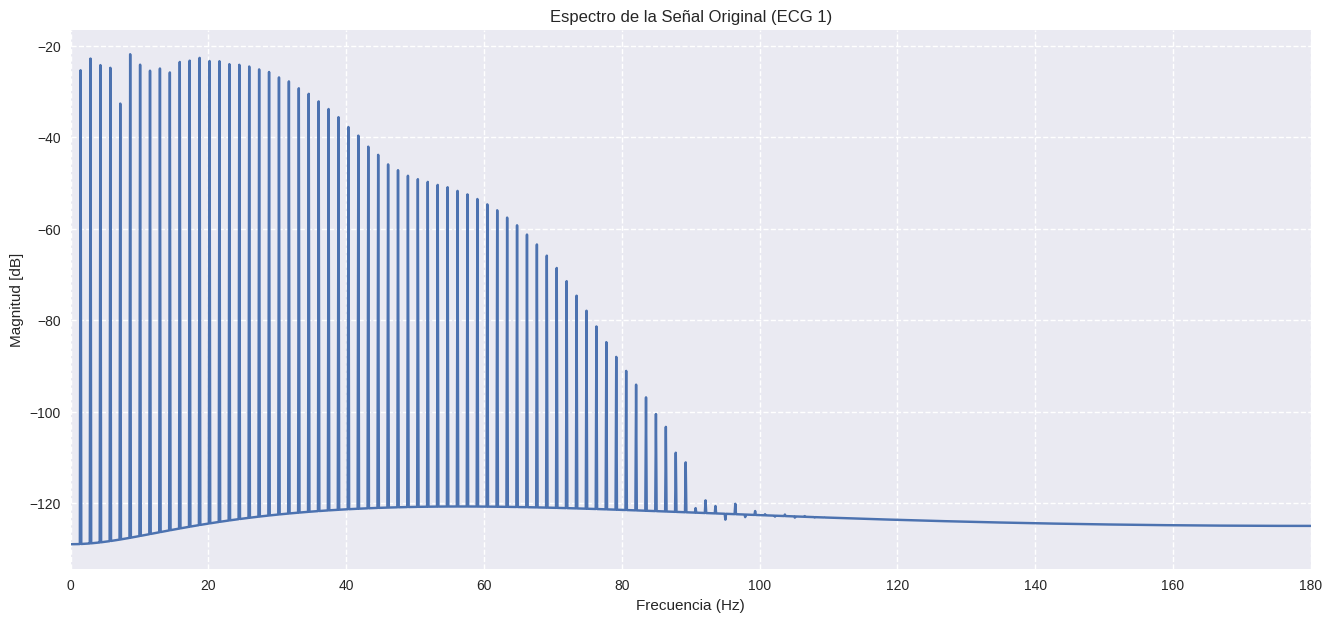

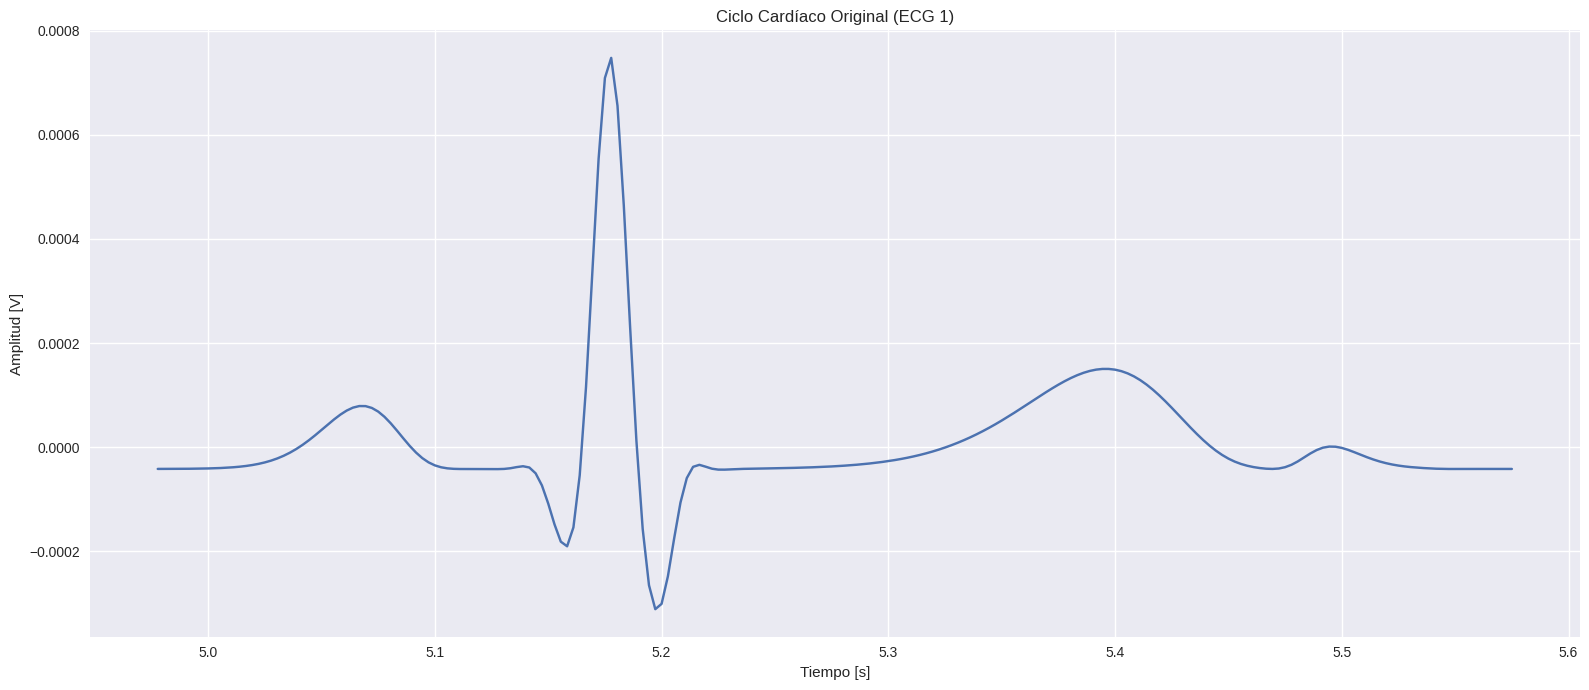


--- Diseñando Filtros ---
Filtro Pasabajos Analógico - Orden: 4, Frecuencia de corte: 39.02 Hz
Filtro Notch Analógico - Orden: 5


/usr/local/lib/python3.11/dist-packages/scipy/signal/_filter_design.py:1125: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


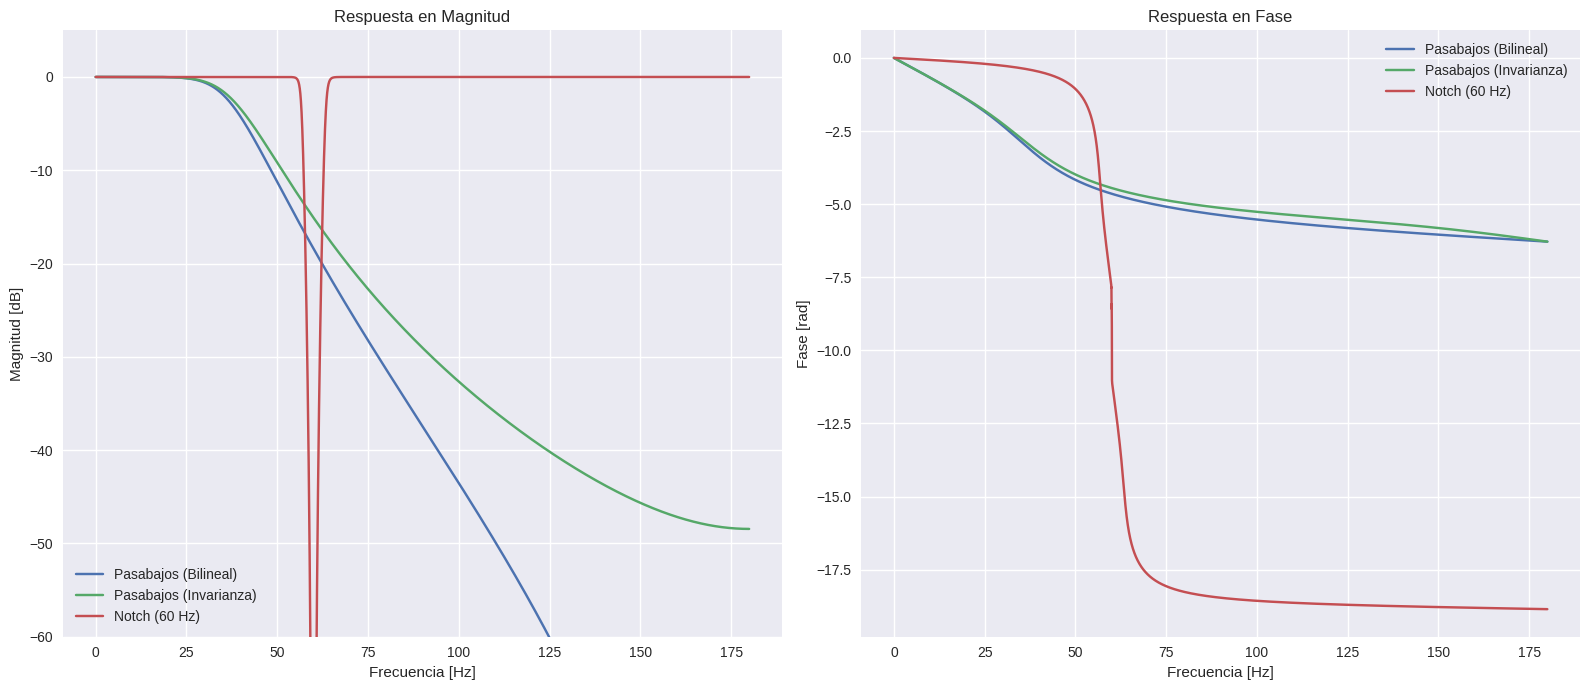


--- Procesando Señales con Filtros en Cascada ---

Procesando con Configuración 1 (Bilineal + Notch):
Tiempo total de procesamiento: 0.0054 s
Tiempo promedio por muestra: 0.5060 µs

Procesando con Configuración 2 (Invarianza + Notch):
Tiempo total de procesamiento: 0.0007 s
Tiempo promedio por muestra: 0.0615 µs

--- Comparando Resultados Finales ---


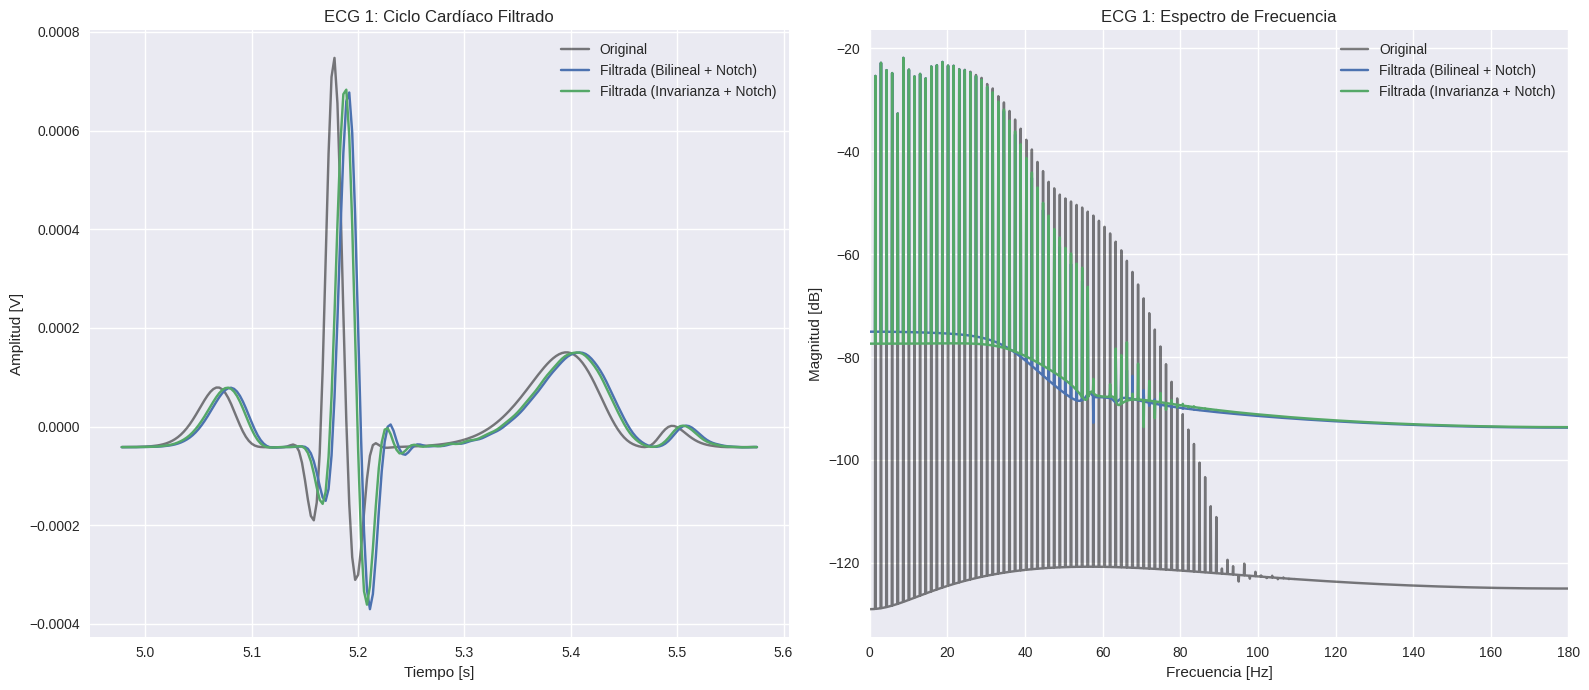

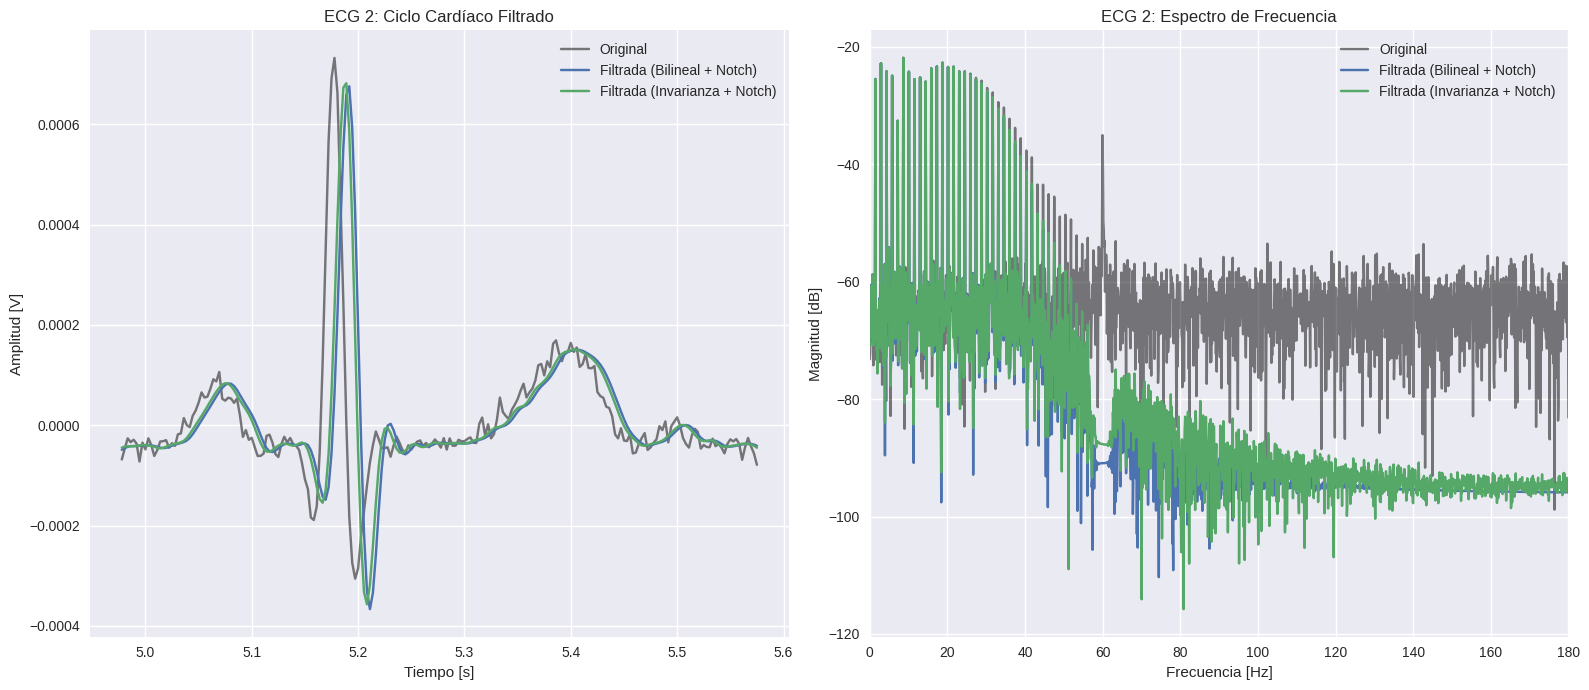

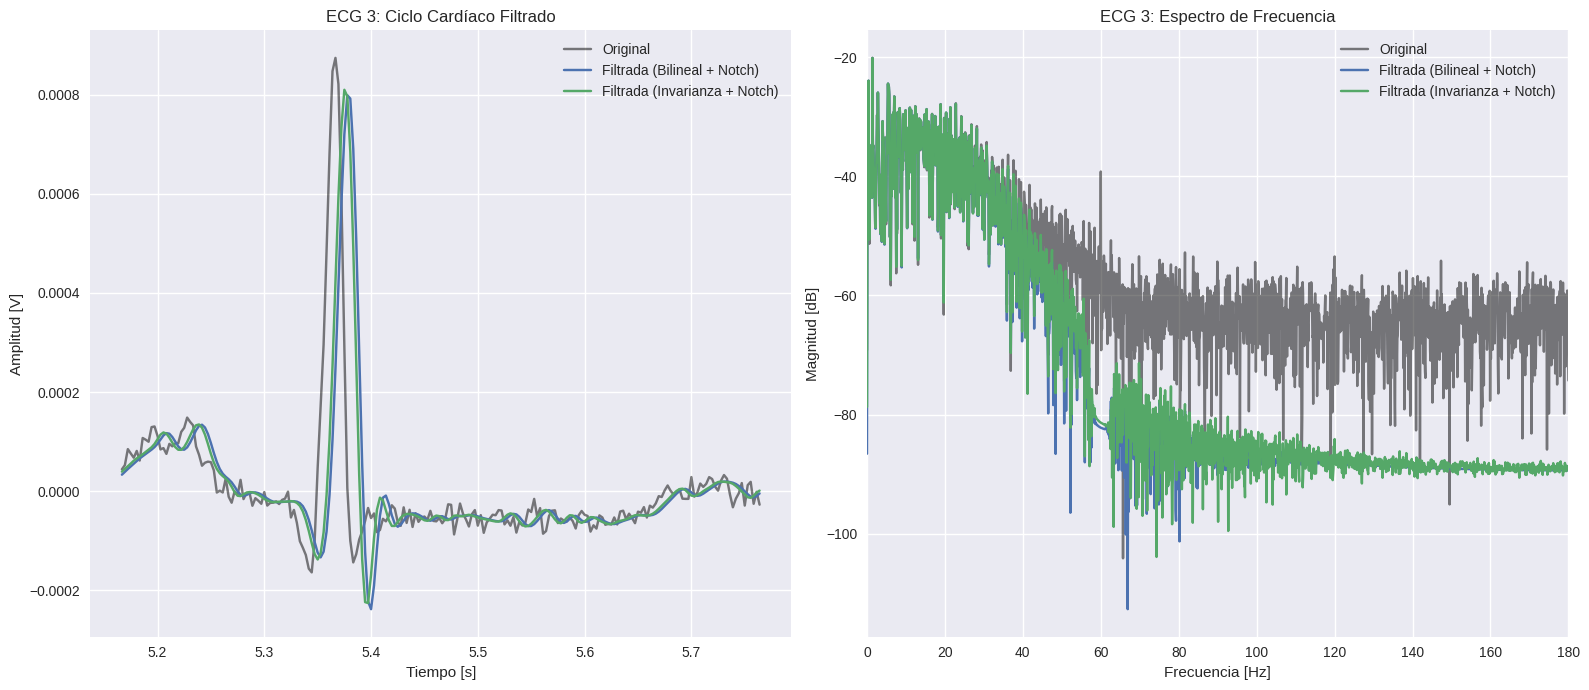

In [ ]:
def main():
    """Función principal para ejecutar todo el flujo de trabajo."""

    # --- 1. Configuración ---
    REPO_URL = "https://github.com/LeandroMurillo/TrabajoFinalPDS"
    BASE_DIR = "/content"
    SAMPLING_RATE = 360  # Hz

    repo_dir = setup_repository(REPO_URL, BASE_DIR)
    ecg_file = os.path.join(repo_dir, "ecg_signal.mat")

    # --- 2. Carga de datos ---
    signals, fs = load_ecg_signals(ecg_file, SAMPLING_RATE)

    # Visualizar una de las señales originales
    plot_signal_spectrum(signals[0], fs, title="Espectro de la Señal Original (ECG 1)")
    plot_cardiac_cycle(signals[0], fs, title="Ciclo Cardíaco Original (ECG 1)")

    # --- 3. Diseño de Filtros ---
    print("\n--- Diseñando Filtros ---")
    # Especificaciones Pasabajos
    lp_fp, lp_fstop, lp_gpass, lp_gstop = 30, 80, 0.5, 20
    (bz_bilin, az_bilin), (bz_invar, az_invar) = design_lowpass_filters(
        lp_fp, lp_fstop, lp_gpass, lp_gstop, fs
    )

    # Especificaciones Notch
    notch_f, notch_bw, notch_gpass, notch_gstop = 60, 4, 1, 20
    bz_notch, az_notch = design_notch_filter(
        notch_f, notch_bw, notch_gpass, notch_gstop, fs
    )

    # Convertir a formato SOS (Second-Order Sections) para la cascada
    sos_lp_bilin = tf2sos(bz_bilin, az_bilin)
    sos_lp_invar = tf2sos(bz_invar, az_invar)
    sos_notch = tf2sos(bz_notch, az_notch)

    # Visualizar respuestas de los filtros
    plot_filter_responses(
        [(bz_bilin, az_bilin), (bz_invar, az_invar), (bz_notch, az_notch)],
        fs,
        ["Pasabajos (Bilineal)", "Pasabajos (Invarianza)", "Notch (60 Hz)"],
    )

    # --- 4. Procesamiento en Cascada ---
    print("\n--- Procesando Señales con Filtros en Cascada ---")

    # Configuración 1: Pasabajos Bilineal + Notch
    print("\nProcesando con Configuración 1 (Bilineal + Notch):")
    processed_bilin, _ = process_signals_in_cascade(signals, [sos_lp_bilin, sos_notch])

    # Configuración 2: Pasabajos Invarianza + Notch
    print("\nProcesando con Configuración 2 (Invarianza + Notch):")
    processed_invar, _ = process_signals_in_cascade(signals, [sos_lp_invar, sos_notch])

    # --- 5. Comparación Final ---
    print("\n--- Comparando Resultados Finales ---")
    for i in range(len(signals)):
        compare_filtered_signals(
            signals[i],
            {
                "Filtrada (Bilineal + Notch)": processed_bilin[i],
                "Filtrada (Invarianza + Notch)": processed_invar[i],
            },
            fs,
            signal_index=i,
        )


if __name__ == "__main__":
    main()